# Delayed Reward Optimization

*  Developed by [Yongtao Liu](https://scholar.google.com/citations?user=V9FMPgQAAAAJ&hl=en) using GPax
*  Update Sep, 2025

# Install and Import

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.cm as cm
import time
import gpax
import numpyro
import jax.random as jra
import jax.numpy as jnp
import random
gpax.utils.enable_x64()
# from sklearn.metrics import mean_squared_error


In [2]:
import matplotlib as mpl
plt.rc('xtick', labelsize=8)
plt.rc('ytick', labelsize=8)
plt.rc('axes', labelsize=8)
mpl.rcParams['figure.dpi'] = 100

# GP function

In [3]:
# Function for performing a GP step, here we use structure GP (sGP)
def run_GP (xtrain, ytrain, xtest, fn = None, fn_priors = None):
  rng_key, rng_key_predict = gpax.utils.get_keys(1)
  # Obtain/update GP posterior
  gp_model = gpax.ExactGP(1, kernel='Matern', mean_fn=fn, mean_fn_prior=fn_priors)
  gp_model.fit(rng_key, xtrain, ytrain)
  # Compute acquisition function
  obj = gpax.acquisition.UE(rng_key_predict, gp_model, xtest)
  # Get GP prediction
  posterior_mean, f_samples = gp_model.predict(rng_key_predict, xtest, n = 200)
  return gp_model, obj, posterior_mean, f_samples

### Initialize training data

In [4]:
# Define a normalization function
def norm_(data):
  return (data - np.min(data)) / (np.max(data) - np.min(data))

# Define a function to simulating sample deposition
def synthesize_sample (composition = None):
    '''
    Sumner: We can insert the PLD simulator here 
    '''
    print ("making sample...")
    time.sleep(3)
    return

In [30]:
# Experiment space: sm composition range
com_spread = 300
sm_composition_spread = np.linspace (0, 20, com_spread)
print ("Sm composition range %: ", min(sm_composition_spread), 'to', max(sm_composition_spread))

# Select random seed experiment conditions
batch_size = 10  # number of samples of each batch
seed_experiments = batch_size # number of seed experiment conditions

random.seed(66)
seed_composition_idxes = sorted(random.sample(range(com_spread), seed_experiments))
print ("Seed samples index: ", seed_composition_idxes)
print ("Seed samples Sm compositions %: ", sm_composition_spread[seed_composition_idxes])

# Prepare data file
all_idxes = np.arange(com_spread)  # idxes of all space
train_idxes = np.array([], dtype = int)  # no sample has been made and measured, so training set is empty
transition_idxes = np.array([], dtype = int)  # no sample has been made, so no sample in transition now
test_idxes = all_idxes  # whole exploration space is test set now

Raw_X = sm_composition_spread   # X is the composition value
X = norm_(Raw_X)  # Actual training X is normalized
y_train = np.array([]) # no sample is measured yet, so y_train is empty now

def flying_saving (): # variable names throughout the notebook need to be consistent
    """Save flying data to 'Flying_Data.npz' using globally defined variables."""
    try:
        np.savez("Flying_Data.npz", all_idxes=all_idxes, train_idxes=train_idxes,
            transition_idxes=transition_idxes, test_idxes=test_idxes,
            Raw_X=Raw_X, X=X, y_train=y_train)
            
        print("Data successfully saved to 'Flying_Data.npz'")
    except NameError as e:
        print(f"Error: {e}. Ensure all required variables are defined before calling this function.")

flying_saving()

Sm composition range %:  0.0 to 20.0
Seed samples index:  [36, 48, 126, 131, 150, 159, 222, 228, 253, 286]
Seed samples Sm compositions %:  [ 2.40802676  3.21070234  8.42809365  8.76254181 10.03344482 10.63545151
 14.84949833 15.25083612 16.92307692 19.13043478]
Data successfully saved to 'Flying_Data.npz'


### Make Seed Samples

In [31]:
def update_transition_idxes (transition_idxes, new_transition_idx):
    """ Append new transition index to the existing transition_idxes array """
    transition_idxes = np.append(transition_idxes, new_transition_idx)
    return transition_idxes

In [ ]:
import glob
from pathlib import Path

def checkin ():
    """Wait until no 'checkin' flag files exist before proceeding.
    
    If another process is reading or writing, a file containing 'checkin' in its name will exist.
    This function repeatedly checks for such files and waits until they are cleared.
    """
    while glob.glob("*checkin*"):  # Checks if any file contains 'checkin' in its name
        print("Checking:", glob.glob("*checkin*"))  # Display found check-in files
        time.sleep(3)  # Wait before checking again
    print("Checked - No check-in files detected.")

def set_flag():
    """Create a 'master_checkin.txt' file to indicate that the process is using the data."""
    Path("master_checkin.txt").touch()  # Creates an empty file

def clear_flag():
    """Remove the 'master_checkin.txt' file after finishing the read/write process."""
    try:
        os.remove("master_checkin.txt")
    except FileNotFoundError:
        print("Warning: 'master_checkin.txt' not found. It may have been removed already.")

def flying_loading ():
    """Load 'Flying_Data.npz' return its content."""
    try:
        return np.load("Flying_Data.npz")
    except FileNotFoundError:
        print("Error: 'Flying_Data.npz' not found.")
        return None

def checkin_flying_loading ():
    """ Load during experiment requires a checkin process"""
    checkin()
    set_flag()
    fly_data = flying_loading()
    time.sleep(1)
    clear_flag()
    return fly_data

In [33]:
# Load existing flying data
flydata = flying_loading()
# Loop through each seed experiment
for exp in range(seed_experiments):
    # Get the composition percentage for the current experiment
    com = sm_composition_spread[seed_composition_idxes[exp]]
    # Synthesize the sample with the given composition
    synthesize_sample(composition=com)
    print(f"Sample with {com}% Sm is made and in transition.")

    # Load the latest transition indexes before updating them
    transition_idxes = flying_loading()["transition_idxes"]
    # Append the new sample index to the transition indexes
    transition_idxes = update_transition_idxes(transition_idxes, seed_composition_idxes[exp])
    # Save the updated transition indexes to the flying data file
    flying_saving()

# Display the final updated transition indexes after all experiments
transition_idxes

making sample...
Sample with 2.4080267558528425% Sm is made and in transition.
Data successfully saved to 'Flying_Data.npz'
making sample...
Sample with 3.2107023411371234% Sm is made and in transition.
Data successfully saved to 'Flying_Data.npz'
making sample...
Sample with 8.42809364548495% Sm is made and in transition.
Data successfully saved to 'Flying_Data.npz'
making sample...
Sample with 8.762541806020067% Sm is made and in transition.
Data successfully saved to 'Flying_Data.npz'
making sample...
Sample with 10.033444816053512% Sm is made and in transition.
Data successfully saved to 'Flying_Data.npz'
making sample...
Sample with 10.635451505016722% Sm is made and in transition.
Data successfully saved to 'Flying_Data.npz'
making sample...
Sample with 14.849498327759196% Sm is made and in transition.
Data successfully saved to 'Flying_Data.npz'
making sample...
Sample with 15.250836120401337% Sm is made and in transition.
Data successfully saved to 'Flying_Data.npz'
making samp

array([ 36,  48, 126, 131, 150, 159, 222, 228, 253, 286])

### Measure Seed Samples

### Measurements are performed in SPM, here we directly load the data

In [34]:
# Load existing flying data from 'Flying_Data.npz'
flydata = flying_loading()

# Extract relevant datasets from the loaded file
X = flydata['X']                  # all data samples
train_idxes = flydata['train_idxes']  # index of training samples
y_train = flydata['y_train']        # results

# Extract training data using train index
X_train = X[train_idxes]
# Extract test data by removing training samples from X
X_test = np.delete(X, train_idxes)

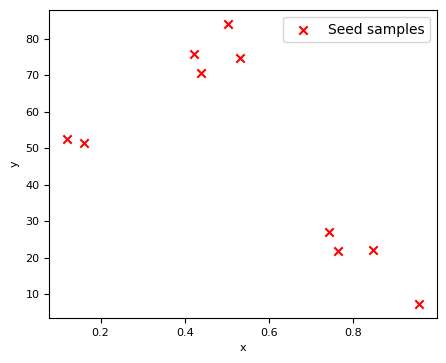

In [35]:
# Plot initial train dataset
plt.figure(figsize = (5, 4))
plt.scatter(X_train, y_train, label = "Seed samples", color = 'red', marker = 'x')
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [37]:
def transition_constraint(x, unwanted_regions, constraint_factor=5):
    """
    Computes a transition constraint based on the samples in transition, 
    Not make samples with closing conditions (unwanted regions) even if the rewards of samples in transition are still unavaiable.

    Parameters:
    - x (float or np.array): The candidate sampling points.
    - unwanted_regions (list or np.array): List of unwanted locations.
    - constraint_index (float): Controls the smoothness and strength of the constraint.

    Returns:
    - constraint (float or np.array): A value between 0 and 1, where lower values mean higher penalties.
    """
    if isinstance(unwanted_regions, (list, np.ndarray)):
        d = np.min([np.abs(x - ur) for ur in unwanted_regions], axis=0)  # Compute distance to closest unwanted region
    else:
        d = np.abs(x - unwanted_regions)

    constraint = np.exp(-constraint_factor*10 * d**2)  # Gaussian constraint
    return 1-constraint

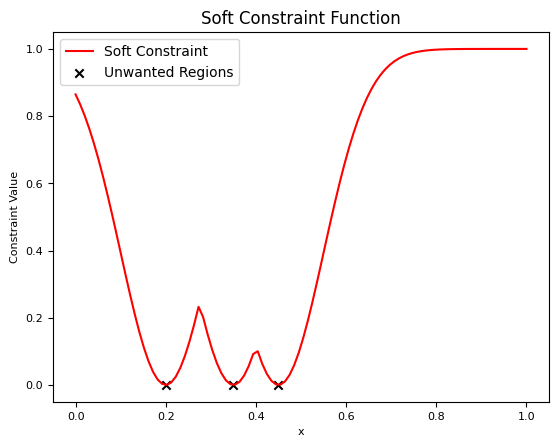

In [38]:
# Define unwanted regions
unwanted_points = np.array([0.2, 0.35, 0.45])  # Avoid sampling near these point

# Test the penalty function at various points
test_x = np.linspace(0, 1, 100)
trans_constraint = transition_constraint(test_x, unwanted_points, constraint_factor=5)

# Plot the penalty function
plt.plot(test_x, trans_constraint, label="Soft Constraint", color="red")
plt.scatter(unwanted_points, [0]*len(unwanted_points), color="black", marker="x", label="Unwanted Regions")
plt.xlabel("x")
plt.ylabel("Constraint Value")
plt.title("Soft Constraint Function")
plt.legend()
plt.show()


In [39]:

def load_trainset ():
    """ Update trainset when there is new sample measured"""
    # Load existing flying data from 'Flying_Data.npz'
    flydata = checkin_flying_loading()

    # Extract relevant datasets from the loaded file
    X = flydata['X']                  # all data samples
    train_idxes = flydata['train_idxes']  # index of training samples
    y_train = flydata['y_train']        # results

    # Extract training data using train index
    X_train = X[train_idxes]
    return X_train, y_train, X_test

def update_transition_idxes (new_sample_idx):
    """ Update transition index when there are new samples added into transition"""
    flydata = checkin_flying_loading()
    
    transition_idxes = flydata["transition_idxes"]
    transition_idxes = np.append(transition_idxes, new_sample_idx)
    return transition_idxes


### Start delayed feedback driven exploration

In [40]:
flydata = checkin_flying_loading()
transition_idxes = flydata['transition_idxes']
test_idxes = flydata['test_idxes']
transition_idxes

Checked - No check-in files detected.


array([], dtype=int32)


Exploration step 1
Checked - No check-in files detected.


sample: 100%|██████████| 4000/4000 [00:01<00:00, 2037.80it/s, 7 steps of size 5.63e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.26      0.07      0.25      0.16      0.36   1208.26      1.00
    k_scale    522.20    199.05    486.19    244.77    813.41   1300.27      1.00
      noise     12.49      7.52     10.43      3.30     22.87   1025.28      1.00

Checked - No check-in files detected.
making sample...
Sample with 0.0% Sm is made and in transition.
Checked - No check-in files detected.
Data successfully saved to 'Flying_Data.npz'


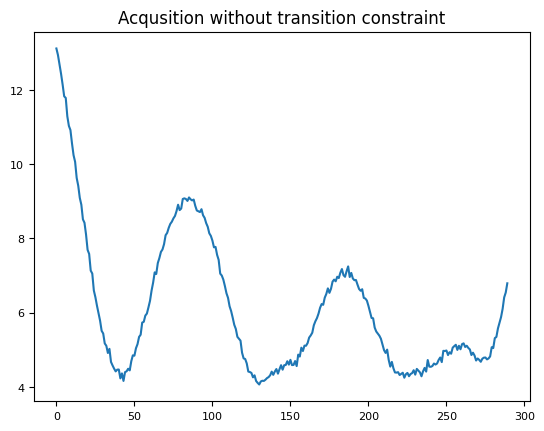

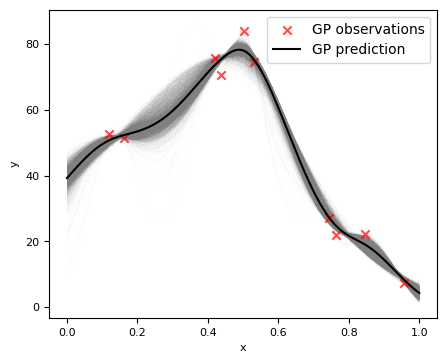


Exploration step 2
Checked - No check-in files detected.


sample: 100%|██████████| 4000/4000 [00:02<00:00, 1935.74it/s, 7 steps of size 5.63e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.26      0.07      0.25      0.16      0.36   1208.26      1.00
    k_scale    522.20    199.05    486.19    244.77    813.41   1300.27      1.00
      noise     12.49      7.52     10.43      3.30     22.87   1025.28      1.00

Checked - No check-in files detected.


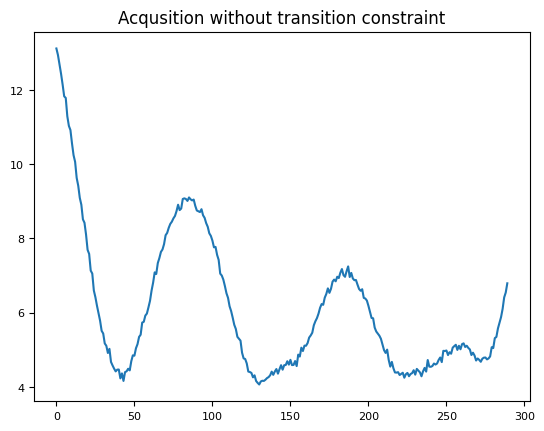

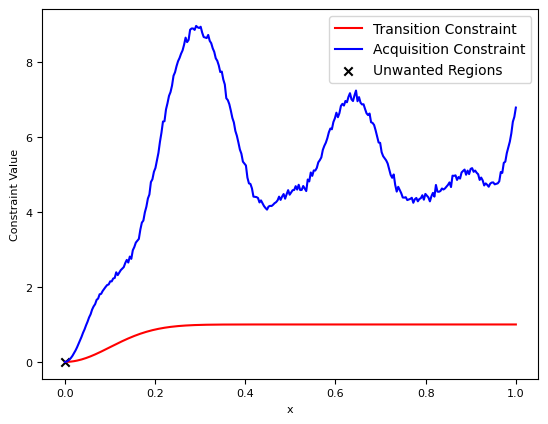

making sample...
Sample with 5.8193979933110365% Sm is made and in transition.
Checked - No check-in files detected.
Data successfully saved to 'Flying_Data.npz'


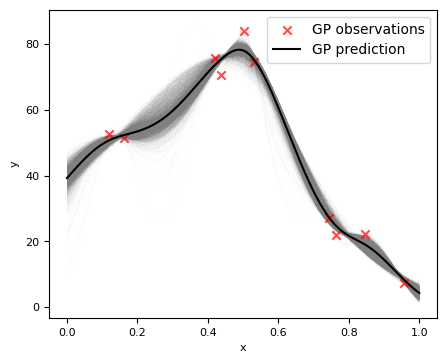


Exploration step 3
Checked - No check-in files detected.


sample: 100%|██████████| 4000/4000 [00:02<00:00, 1980.22it/s, 7 steps of size 5.63e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.26      0.07      0.25      0.16      0.36   1208.26      1.00
    k_scale    522.20    199.05    486.19    244.77    813.41   1300.27      1.00
      noise     12.49      7.52     10.43      3.30     22.87   1025.28      1.00

Checked - No check-in files detected.


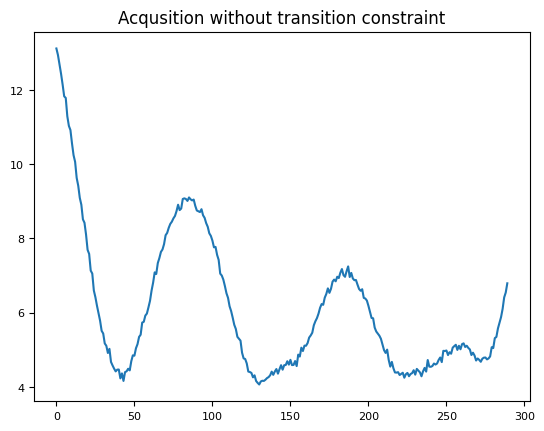

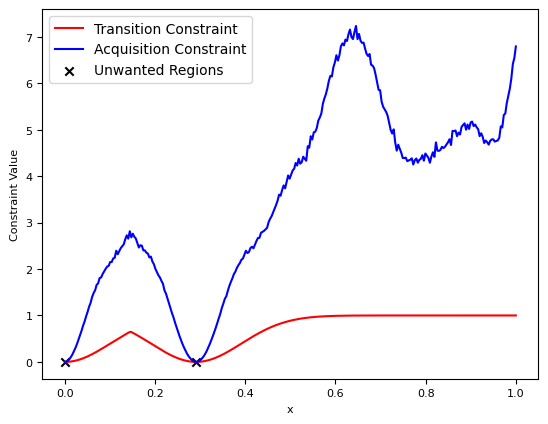

making sample...
Sample with 12.909698996655518% Sm is made and in transition.
Checked - No check-in files detected.
Data successfully saved to 'Flying_Data.npz'


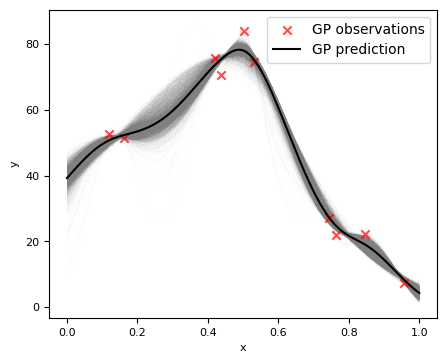


Exploration step 4
Checked - No check-in files detected.


sample: 100%|██████████| 4000/4000 [00:02<00:00, 1709.77it/s, 7 steps of size 5.63e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.26      0.07      0.25      0.16      0.36   1208.26      1.00
    k_scale    522.20    199.05    486.19    244.77    813.41   1300.27      1.00
      noise     12.49      7.52     10.43      3.30     22.87   1025.28      1.00

Checked - No check-in files detected.


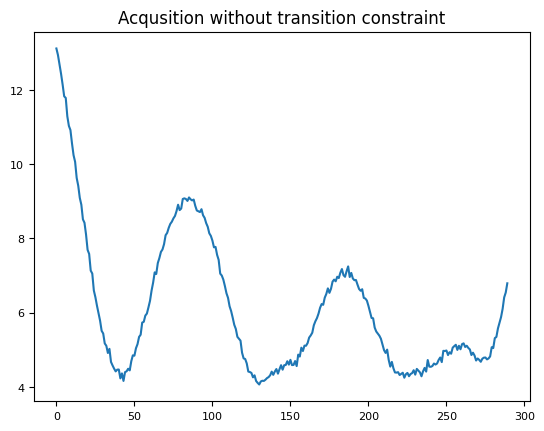

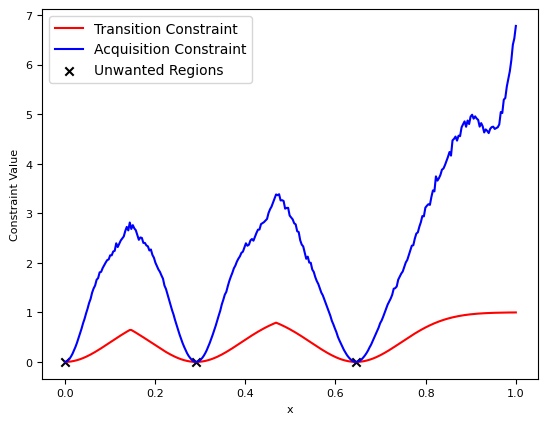

making sample...
Sample with 20.0% Sm is made and in transition.
Checked - No check-in files detected.
Data successfully saved to 'Flying_Data.npz'


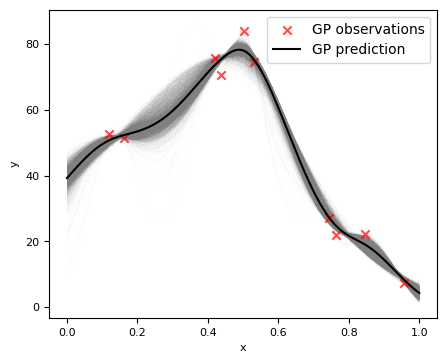


Exploration step 5
Checked - No check-in files detected.


sample: 100%|██████████| 4000/4000 [00:02<00:00, 1909.99it/s, 7 steps of size 5.63e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.26      0.07      0.25      0.16      0.36   1208.26      1.00
    k_scale    522.20    199.05    486.19    244.77    813.41   1300.27      1.00
      noise     12.49      7.52     10.43      3.30     22.87   1025.28      1.00

Checked - No check-in files detected.


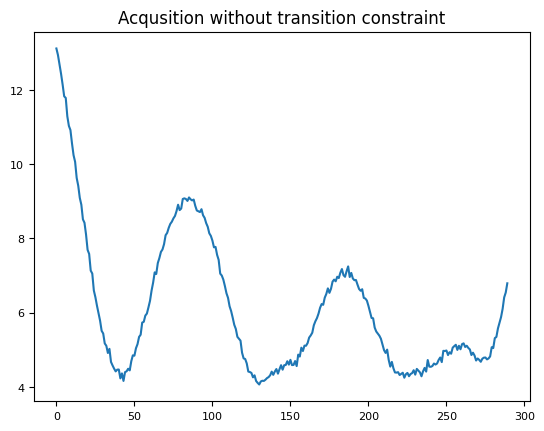

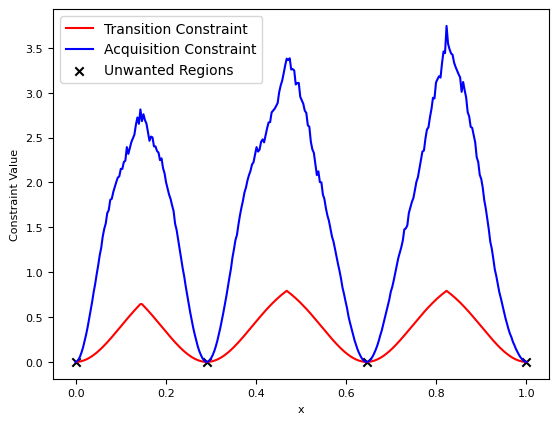

making sample...
Sample with 16.454849498327757% Sm is made and in transition.
Checked - No check-in files detected.
Data successfully saved to 'Flying_Data.npz'


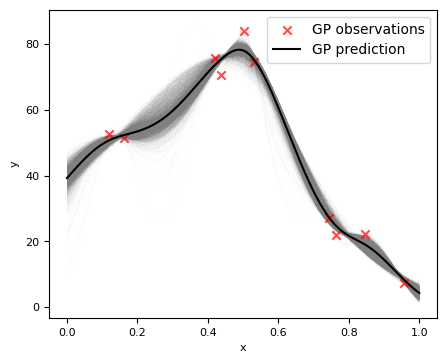


Exploration step 6
Checked - No check-in files detected.


sample: 100%|██████████| 4000/4000 [00:02<00:00, 1930.23it/s, 7 steps of size 5.63e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.26      0.07      0.25      0.16      0.36   1208.26      1.00
    k_scale    522.20    199.05    486.19    244.77    813.41   1300.27      1.00
      noise     12.49      7.52     10.43      3.30     22.87   1025.28      1.00

Checked - No check-in files detected.


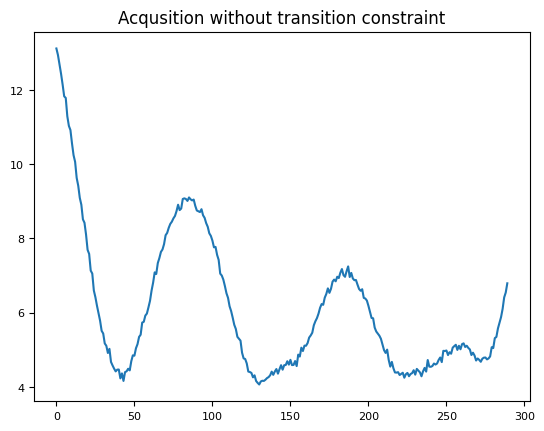

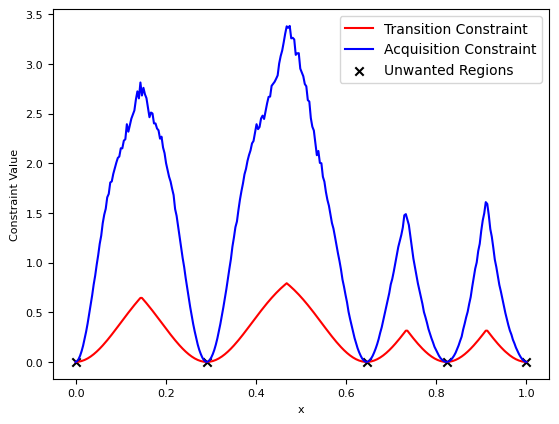

making sample...
Sample with 9.498327759197323% Sm is made and in transition.
Checked - No check-in files detected.
Data successfully saved to 'Flying_Data.npz'


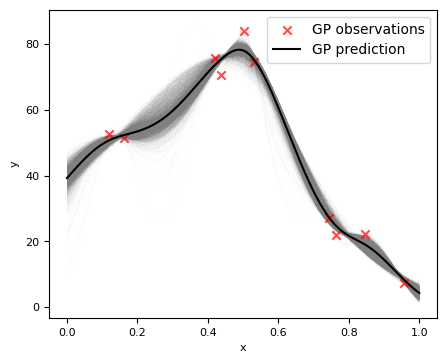


Exploration step 7
Checked - No check-in files detected.


sample: 100%|██████████| 4000/4000 [00:02<00:00, 1858.03it/s, 7 steps of size 5.63e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.26      0.07      0.25      0.16      0.36   1208.26      1.00
    k_scale    522.20    199.05    486.19    244.77    813.41   1300.27      1.00
      noise     12.49      7.52     10.43      3.30     22.87   1025.28      1.00

Checked - No check-in files detected.


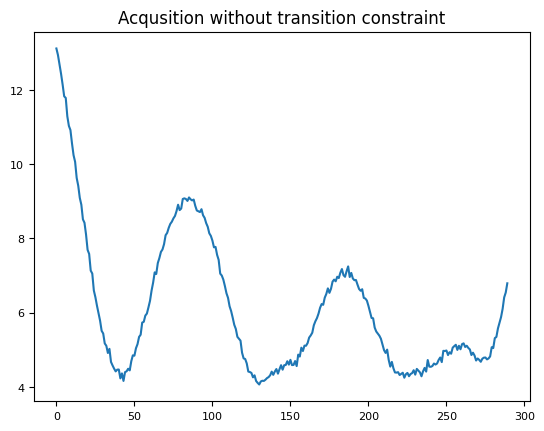

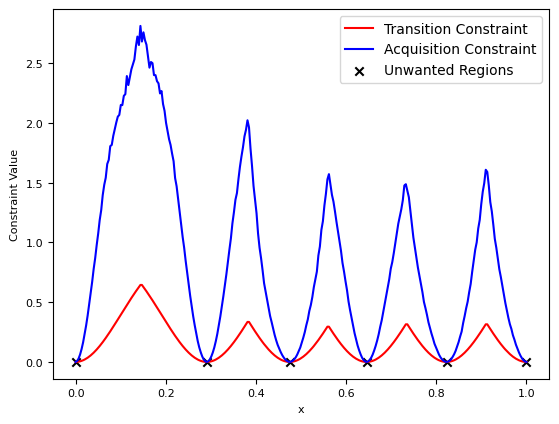

making sample...
Sample with 2.8762541806020065% Sm is made and in transition.
Checked - No check-in files detected.
Data successfully saved to 'Flying_Data.npz'


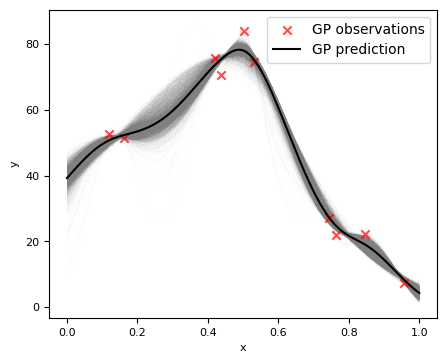


Exploration step 8
Checked - No check-in files detected.


sample: 100%|██████████| 4000/4000 [00:01<00:00, 2007.66it/s, 7 steps of size 5.63e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.26      0.07      0.25      0.16      0.36   1208.26      1.00
    k_scale    522.20    199.05    486.19    244.77    813.41   1300.27      1.00
      noise     12.49      7.52     10.43      3.30     22.87   1025.28      1.00

Checked - No check-in files detected.


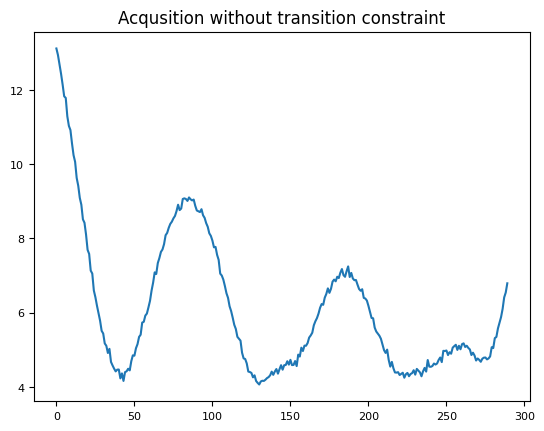

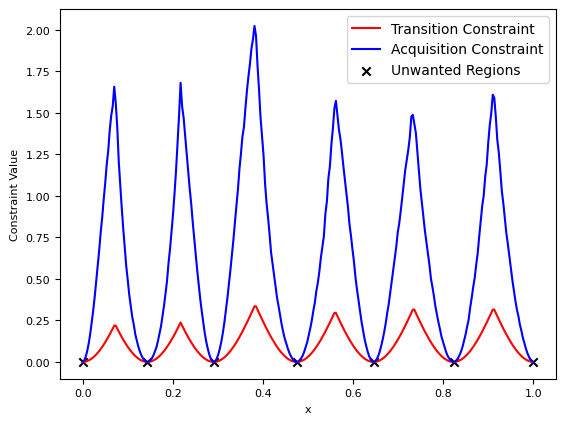

making sample...
Sample with 7.625418060200668% Sm is made and in transition.
Checked - No check-in files detected.
Data successfully saved to 'Flying_Data.npz'


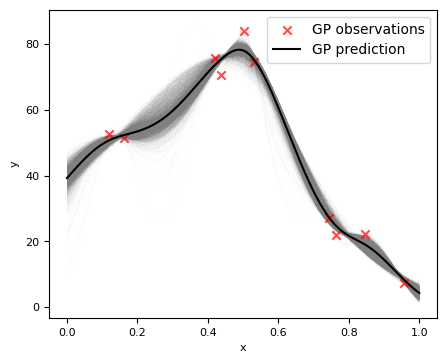


Exploration step 9
Checked - No check-in files detected.


sample: 100%|██████████| 4000/4000 [00:01<00:00, 2104.69it/s, 7 steps of size 5.63e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.26      0.07      0.25      0.16      0.36   1208.26      1.00
    k_scale    522.20    199.05    486.19    244.77    813.41   1300.27      1.00
      noise     12.49      7.52     10.43      3.30     22.87   1025.28      1.00

Checked - No check-in files detected.


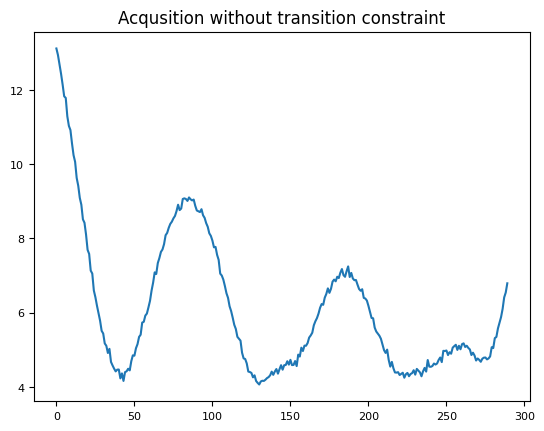

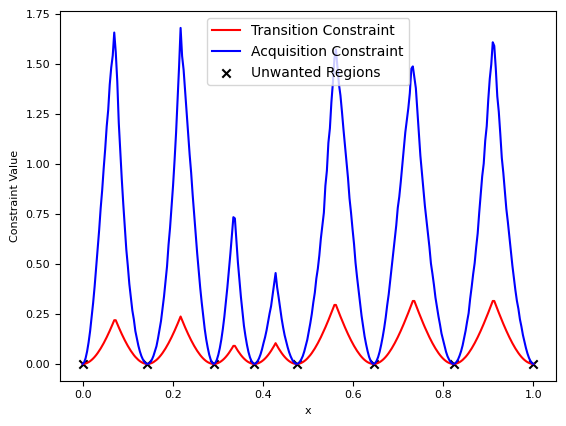

making sample...
Sample with 4.3478260869565215% Sm is made and in transition.
Checked - No check-in files detected.
Data successfully saved to 'Flying_Data.npz'


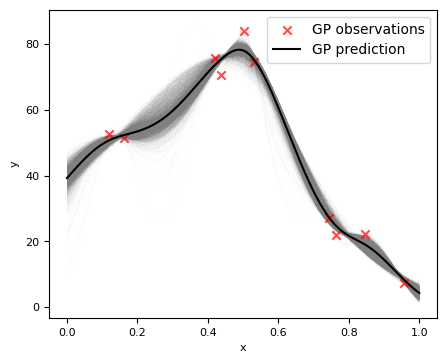


Exploration step 10
Checked - No check-in files detected.


sample: 100%|██████████| 4000/4000 [00:02<00:00, 1575.22it/s, 7 steps of size 5.63e-01. acc. prob=0.94]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.26      0.07      0.25      0.16      0.36   1208.26      1.00
    k_scale    522.20    199.05    486.19    244.77    813.41   1300.27      1.00
      noise     12.49      7.52     10.43      3.30     22.87   1025.28      1.00

Checking: ['measurement_checkin.txt']
Checking: ['measurement_checkin.txt']
Checking: ['measurement_checkin.txt']
Checking: ['measurement_checkin.txt']
Checking: ['measurement_checkin.txt']
Checking: ['measurement_checkin.txt']
Checking: ['measurement_checkin.txt']
Checking: ['measurement_checkin.txt']
Checking: ['measurement_checkin.txt']
Checking: ['measurement_checkin.txt']
Checking: ['measurement_checkin.txt']
Checking: ['measurement_checkin.txt']
Checking: ['measurement_checkin.txt']
Checking: ['measurement_checkin.txt']
Checked - No check-in files detected.
making sample...
Sample with 0.06688963210702341% Sm is made and in transition.
Checked - No check-i

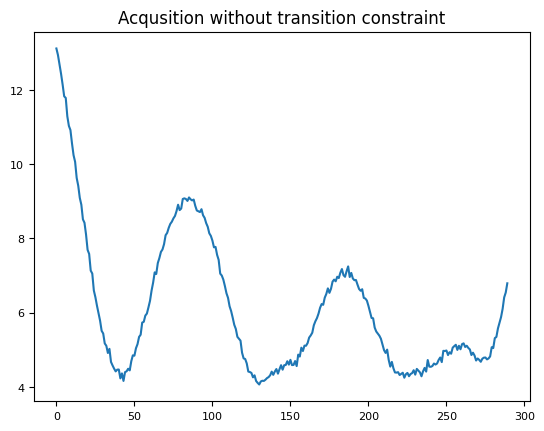

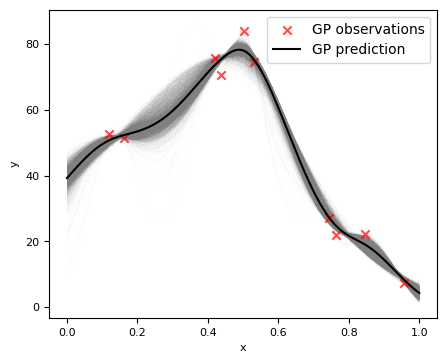


Exploration step 11
Checked - No check-in files detected.


sample: 100%|██████████| 4000/4000 [00:02<00:00, 1850.32it/s, 7 steps of size 5.63e-01. acc. prob=0.94] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.26      0.07      0.25      0.16      0.36   1208.26      1.00
    k_scale    522.20    199.05    486.19    244.77    813.41   1300.27      1.00
      noise     12.49      7.52     10.43      3.30     22.87   1025.28      1.00

Checked - No check-in files detected.


TypeError: mul got incompatible shapes for broadcasting: (290,), (281,).

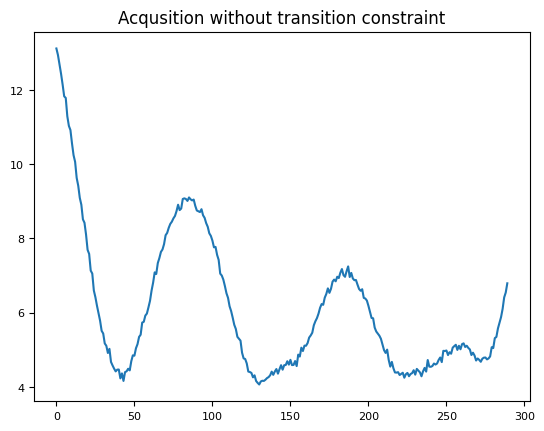

In [41]:
rng_key, rng_key_predict = gpax.utils.get_keys(1)
exploration_steps = 50

for i in range(exploration_steps):
    print("\nExploration step {}".format(i+1))
    ### Load current dataset ###
    
    # Execute GP
    X_train, y_train, X_test = load_trainset()   # Load train dataset
    gpbo, obj, posterior_mean, f_samples = run_GP(X_train, y_train, X_test)  #run GP
    plt.figure()
    plt.plot(obj)
    plt.title("Acqusition without transition constraint")
    # Look into if there are samples in transition
    flydata = checkin_flying_loading()
    transition_idxes = flydata['transition_idxes']
    test_idxes = flydata['test_idxes']
    if len(transition_idxes) != 0:
      trans_constraint = transition_constraint(X[test_idxes], X[transition_idxes], constraint_factor=5)
      obj = obj*trans_constraint
      plt.figure()
      plt.plot(X_test, trans_constraint, label="Transition Constraint", color="red")
      plt.plot(X_test, obj, label="Acquisition Constraint", color="blue")
      plt.scatter(X[transition_idxes], [0]*len(transition_idxes), color="black", marker="x", label="Unwanted Regions")
      plt.xlabel("x")
      plt.ylabel("Constraint Value")
      plt.legend()
      plt.show()
    # Next point
    next_point = obj.argmax()
    next_sample_index = test_idxes[next_point]

    # Get the composition percentage for the current experiment
    com = sm_composition_spread[next_sample_index]
    # Synthesize the sample with the given composition
    synthesize_sample(composition=com)
    print(f"Sample with {com}% Sm is made and in transition.")
    # update sample in transition
    transition_idxes = update_transition_idxes(next_sample_index)
    # Save the updated transition indexes to the flying data file
    flying_saving()

    # Plot results-------------------------
    fig, ax = plt.subplots(1, 1, figsize=(5, 4))
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.scatter(X_train, y_train, marker='x', c='r', zorder=1, label="GP observations", alpha=0.7)
    for y1 in f_samples:
      ax.plot(X_test, y1.mean(0), lw=.1, zorder=0, c='Gray', alpha=.1)
    l, = ax.plot(X_test, f_samples[0].mean(0), lw=1, c='Gray', alpha=1)
    ax.plot(X_test, posterior_mean, lw=1.5, zorder=1, c='black', label='GP prediction')
    ax.legend();
    l.set_alpha(0)
    plt.show()